# 05_predict_2026.ipynb　概要
- 個人住民税予測モデル - Step5: 翌年度予測（デフォルト: 2026年）
- 04_model_train.py で保存したモデルを使い、翌年の個人別住民税額を予測する。
- 実データがない場合は直近年をベースに給与・所得トレンドを外挿して推計する。
- tax_reform_config.csv の feature_correction を適用して税制改正を特徴量に反映する。

## input
- data/03out_individual_prepared.csv   ← 03 の出力
- models/lgbm_model.txt          ← 04 の出力
- models/model_config.json       ← 04 の出力
- config.py                      ← モデル設定（特徴量・パラメータ・学習年・テスト年）
- tax_reform_config.csv          ← 税制改正設定ファイル

## output
- data/05out_prediction_YYYY.csv         ← 個人別予測値（信頼区間付き）
- data/05out_prediction_summary_YYYY.csv ← 合計・信頼区間サマリー

## 実行モードの設定
NOTEBOOK_ARGS は下部の「notebook実行モードの指定」セクションで指定する（--year, --file, --wage-rate / --wage-delta などの切替）

---

# ファイルパス設定 / ライブラリインポート

03_notebooks/ から実行してもプロジェクトルート基準の相対パス（data/, models/, tax_reform, config）が解決できるよう、カレントディレクトリをルートへ戻す

In [1]:
import os
import sys
if os.path.basename(os.getcwd()) == "03_notebooks":
    os.chdir("..")
# config.py / tax_reform.py はこのノートブックと同じ 03_notebooks/ にあるため、
# ルートへchdirした後もそこを参照できるよう sys.path に追加する（2026-09-12変更）
sys.path.insert(0, os.path.join(os.getcwd(), "03_notebooks"))

In [2]:
import argparse
import json
import logging
import os
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import lightgbm as lgb
# 以下はnotebook専用（結果サマリーを表として描画するため）。CLI版の05_predict_2026.pyでは未使用。
import matplotlib
import matplotlib.pyplot as plt
from tax_reform import (
    load_reforms, apply_reforms, print_reform_summary,
    compute_salary_income, compute_basic_deduction,
    estimate_furusato_resident_deduction, compute_non_taxable_flag,
)
from config import (
    PREPARED_DATA_PATH, MODEL_PATH, MODEL_CONFIG_PATH, REFORM_CONFIG_PATH,
    PREDICT_YEAR, FEATURE_COLS, TARGET_COL,
    FURUSATO_PARAMS, HOUSING_PARAMS, MIN_TAX, CONFORMAL_COVERAGE,
    WAGE_RATE_OVERRIDE, WAGE_RATE_DELTA, LGBM_PARAMS, ALL_INCOME_COLS,
)

matplotlib.rcParams["font.family"] = ["MS Gothic", "Hiragino Sans", "DejaVu Sans"]
matplotlib.rcParams["axes.unicode_minus"] = False
# "findfont: Font family 'Hiragino Sans' not found" は matplotlib.font_manager が
# logging 経由で出す警告であり、warnings.filterwarnings では抑制できないため個別に抑制する
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)


---

## notebook実行モードの指定

このスクリプトは元々 `python 05_predict_2026.py --year 2027` のようにCLI引数でモードを切り替える設計。
notebook上にはコマンドライン引数がないため、`NOTEBOOK_ARGS` にCLIと同じ文字列のリストを指定することで
`argparse` にそのまま渡す（`main()` 内の `parser.parse_args()` を `parser.parse_args(NOTEBOOK_ARGS)` に変更）。

- `[]`                                  : 引数なし実行と同じ（PREDICT_YEAR・自動推計モード）
- `["--year", "2027"]`                  : 予測年度を変更
- `["--file", "data/individual_2026_input.csv"]` : 実データCSVを使用
- `["--wage-rate", "0.025"]`            : 給与上昇率を直接指定（+2.5%）
- `["--wage-delta", "0.013"]`           : 実績トレンド + 1.3%

In [3]:
NOTEBOOK_ARGS = []  # 実行したいモードに応じて上のセルの例のように書き換える

In [4]:
parser = argparse.ArgumentParser()
parser.add_argument("--year", type=int, default=PREDICT_YEAR,
                    help=f"予測年度（デフォルト: {PREDICT_YEAR}）")
parser.add_argument("--file", default=None,
                    help="実データCSVパス（省略時は直近年から自動推計）")
wage_grp = parser.add_mutually_exclusive_group()
wage_grp.add_argument("--wage-rate",  type=float, default=None,
                      help="給与収入上昇率を直接指定（例: 0.025 → +2.5%)")
wage_grp.add_argument("--wage-delta", type=float, default=WAGE_RATE_DELTA,
                      help="実績トレンドへの加算値（例: 0.013 → +1.3%)")
args = parser.parse_args(NOTEBOOK_ARGS)  # notebook上ではCLI引数の代わりに NOTEBOOK_ARGS を使用

print(f"=== 05: {args.year}年度 予測 ===")

=== 05: 2026年度 予測 ===


---

# 関数設定

## モデル設定 JSON の読み込み

In [5]:
def load_model_config(path: str) -> dict:
    with open(path, encoding="utf-8") as f:
        config = json.load(f)
    config.setdefault("min_tax", MIN_TAX)
    return config

## 住宅借入金等特別控除　翌年推計

In [6]:
def _estimate_housing_credit(
    prev_df: pd.DataFrame,
    n: int,
    rng: np.random.Generator,
) -> np.ndarray:
    if "deduct_tax_housing" not in prev_df.columns:
        return np.zeros(n, dtype=int)
    prev_housing = prev_df["deduct_tax_housing"].values.astype(float)
    keep         = rng.random(n) >= HOUSING_PARAMS["annual_exit_rate"]
    result       = np.where(keep, prev_housing, 0.0)
    return np.minimum(result, HOUSING_PARAMS["upper_limit"]).round(0).astype(int)

## Split Conformal Prediction（信頼区間）

In [7]:
def compute_conformal_interval(
    config: dict,
    df_prep: pd.DataFrame,
    feature_cols: list,
    coverage: float,
) -> tuple[float, np.ndarray]:
    """
    TEST_YEAR のホールドアウト残差を使って信頼区間幅（±q）を計算する。
    04 と同じ label_correction を適用してから residual を取る。
    """
    label_reforms = load_reforms(
        REFORM_CONFIG_PATH,
        target_year=max(config["train_years"] + [config["test_year"]]),
        reform_type="label_correction",
    )
    df_corrected = apply_reforms(df_prep.copy(), label_reforms)
    df_train     = df_corrected[df_corrected["year"].isin(config["train_years"])].copy()
    df_test      = df_corrected[df_corrected["year"] == config["test_year"]].copy()

    model_c = lgb.LGBMRegressor(**config["lgbm_params"])
    model_c.fit(
        df_train[feature_cols].fillna(0).values,
        df_train[TARGET_COL].values,
        callbacks=[lgb.log_evaluation(period=-1)],
    )
    pred_calib = np.maximum(
        model_c.predict(df_test[feature_cols].fillna(0).values),
        config["min_tax"],
    )
    actual_calib = df_prep[df_prep["year"] == config["test_year"]][TARGET_COL].values
    scores = np.abs(actual_calib - pred_calib)
    q      = float(np.quantile(scores, coverage))
    return q, scores

## 直近年ベースの翌年レコード推計

In [8]:
def estimate_next_year(
    df: pd.DataFrame,
    target_year: int,
    wage_rate: float | None,
    wage_delta: float,
) -> pd.DataFrame:
    last_year = df["year"].max()
    base_df   = df[df["year"] == last_year].copy()

    has_gross        = "income_salary_gross" in df.columns
    salary_trend_col = "income_salary_gross" if has_gross else "income_salary"

    trend_cols = [salary_trend_col, "income_business", "income_pension", "income_total"]
    yoy_rates  = {}
    for col in trend_cols:
        if col in df.columns:
            yr_means = df.groupby("year")[col].mean()
            yoy_rates[col] = (
                float(yr_means.pct_change().dropna().tail(2).mean())
                if len(yr_means) >= 2 else 0.0
            )

    base_wage_rate = yoy_rates.get(salary_trend_col, 0.0)
    if wage_rate is not None:
        eff_wage_rate = wage_rate
        print(f"  給与収入上昇率（直接指定）: {eff_wage_rate*100:+.2f}%")
        print(f"  （実績トレンド参考値: {base_wage_rate*100:+.2f}%）")
    elif wage_delta != 0.0:
        eff_wage_rate = base_wage_rate + wage_delta
        print(f"  給与収入上昇率: 実績 {base_wage_rate*100:+.2f}% + 差分 {wage_delta*100:+.2f}% = {eff_wage_rate*100:+.2f}%")
    else:
        eff_wage_rate = base_wage_rate
        print(f"  給与収入上昇率（実績トレンド直近2年平均）: {eff_wage_rate*100:+.2f}%")

    for col in ["income_business", "income_pension", "income_total"]:
        if col in yoy_rates:
            print(f"  {col}: {yoy_rates[col]*100:+.2f}%")

    rng     = np.random.default_rng(42)
    next_df = base_df.copy()
    next_df["year"]              = target_year
    next_df["prev_income_total"] = next_df["income_total"]
    next_df["prev_tax_amount"]   = next_df["tax_amount"]
    if "taxable_income" in next_df.columns:
        next_df["prev_taxable_income"] = next_df["taxable_income"]
    next_df["is_continuing"] = 1

    noise = rng.normal(1.0, 0.02, size=len(next_df))

    if has_gross:
        next_df["income_salary_gross"] = (
            next_df["income_salary_gross"] * (1 + eff_wage_rate) * noise
        ).clip(0).round(0).astype(int)
        next_df["income_salary"] = (
            compute_salary_income(next_df["income_salary_gross"].values, year=target_year)
        ).round(0).astype(int)
    else:
        next_df["income_salary"] = (
            next_df["income_salary"] * (1 + eff_wage_rate) * noise
        ).clip(0).round(0).astype(int)

    # 事業所得・年金収入（gross）にトレンドを適用。年金所得は収入から再計算
    for col in ["income_business", "income_pension_gross"]:
        if col in next_df.columns:
            rate  = yoy_rates.get(col, 0.0)
            noise = rng.normal(1.0, 0.02, size=len(next_df))
            next_df[col] = (next_df[col] * (1 + rate) * noise).clip(0).round(0).astype(int)
    if "income_pension_gross" in next_df.columns:
        from tax_reform import compute_pension_income
        next_df["income_pension"] = compute_pension_income(
            next_df["income_pension_gross"].values, next_df["age"].values
        ).round(0).astype(int)
    elif "income_pension" in next_df.columns:
        rate  = yoy_rates.get("income_pension", 0.0)
        noise = rng.normal(1.0, 0.02, size=len(next_df))
        next_df["income_pension"] = (next_df["income_pension"] * (1 + rate) * noise).clip(0).round(0).astype(int)

    inc_cols = [c for c in ALL_INCOME_COLS if c in next_df.columns]
    next_df["income_total"] = next_df[inc_cols].sum(axis=1)
    next_df["income_yoy_change"] = next_df["income_total"] - next_df["prev_income_total"]

    gross_for_deduct = (
        next_df["income_salary_gross"] if has_gross else next_df["income_salary"]
    )
    next_df["deduct_social_ins"] = (gross_for_deduct * 0.14).round(0).astype(int)
    next_df["deduct_basic"]      = (
        compute_basic_deduction(next_df["income_total"].values)
    ).round(0).astype(int)

    deduct_cols = [
        "deduct_social_ins", "deduct_small_biz_ins", "deduct_life_ins",
        "deduct_earthquake_ins", "deduct_casualty", "deduct_medical",
        "deduct_disability", "deduct_widow", "deduct_spouse", "deduct_spouse_special",
        "deduct_dependent", "deduct_basic", "deduct_working_student",
        "deduct_donation_income",
    ]
    next_df["deduct_total"] = sum(
        next_df[c] for c in deduct_cols if c in next_df.columns
    )

    safe_total = next_df["income_total"].replace(0, np.nan)
    next_df["deduct_rate"]  = (next_df["deduct_total"] / safe_total).fillna(0).clip(0, 1)
    next_df["taxable_income"] = (
        next_df["income_total"] - next_df["deduct_total"]
    ).clip(0).round(0).astype(int)
    next_df["taxable_rate"] = (
        next_df["taxable_income"] / safe_total
    ).fillna(0).clip(0, 1)

    # 税額控除推計
    print("  税額控除推計:")
    next_df["deduct_tax_housing"] = _estimate_housing_credit(base_df, len(next_df), rng)
    next_df["deduct_tax_furusato"] = estimate_furusato_resident_deduction(
        next_df["taxable_income"].values,
        donation_rate=FURUSATO_PARAMS["donation_rate"],
        one_stop_ratio=FURUSATO_PARAMS["one_stop_ratio"],
    ).astype(int)

    n_h   = int((next_df["deduct_tax_housing"]  > 0).sum())
    oku_h = next_df["deduct_tax_housing"].sum()  / 1e8
    oku_f = next_df["deduct_tax_furusato"].sum() / 1e8
    print(f"    住宅ローン控除  : {oku_h:.3f}億円 ({n_h:,}人対象)")
    print(f"    ふるさと納税控除: {oku_f:.3f}億円 (寄付率 {FURUSATO_PARAMS['donation_rate']*100:.1f}%)")

    return next_df

---

# 前処理

## モデル設定読込・データ読込

In [9]:
if not os.path.exists(MODEL_CONFIG_PATH):
    raise FileNotFoundError(f"{MODEL_CONFIG_PATH} がありません。先に 04_model_train.py を実行してください。")

## config.py で設定 MODEL_CONFIG_PATH = "models/model_config.json"
config       = load_model_config(MODEL_CONFIG_PATH)
feature_cols = config["feature_cols"]
min_tax      = config["min_tax"]

df_prep = pd.read_csv(PREPARED_DATA_PATH, encoding="utf-8-sig")
df_prep[feature_cols] = df_prep[feature_cols].fillna(0)

---

# 実行

## 全年度再学習

In [10]:
# 全年度（label_correction 済み）で再学習
label_reforms = load_reforms(
    REFORM_CONFIG_PATH,
    target_year=max(config["train_years"] + [config["test_year"]]),
    reform_type="label_correction",
)
df_for_train = apply_reforms(df_prep.copy(), label_reforms)
model        = lgb.LGBMRegressor(**config["lgbm_params"])
all_years    = sorted(df_for_train["year"].unique().tolist())
print(f"全年度再学習中... {all_years}（{len(df_for_train):,} 件）")
model.fit(
    df_for_train[feature_cols].values,
    df_for_train[TARGET_COL].values,
    callbacks=[lgb.log_evaluation(period=-1)],
)
print("完了")

全年度再学習中... [2020, 2021, 2022, 2023, 2024, 2025]（597,000 件）


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.044795 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10361
[LightGBM] [Info] Number of data points in the train set: 597000, number of used features: 62
[LightGBM] [Info] Start training from score 184520.097402


完了


## 信頼区間キャリブレーション

In [11]:
print("信頼区間キャリブレーション中...")
q_cov, calib_scores = compute_conformal_interval(
    config, df_prep, feature_cols, coverage=CONFORMAL_COVERAGE
)
print(f"  {CONFORMAL_COVERAGE*100:.0f}%区間幅: ±{q_cov/1e4:.1f}万円/人")

信頼区間キャリブレーション中...


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.056264 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10469
[LightGBM] [Info] Number of data points in the train set: 498200, number of used features: 62
[LightGBM] [Info] Start training from score 182311.460755


  95%区間幅: ±0.5万円/人


## 予測データ準備と予測

In [12]:
if args.file:
    print(f"実データ読込: {args.file}")
    pred_df      = pd.read_csv(args.file, encoding="utf-8-sig")
    pred_df[feature_cols] = pred_df[feature_cols].fillna(0)
    feature_reforms = []
    pred_df_out  = pred_df
    X            = pred_df[feature_cols].fillna(0).values
    pred_tax     = np.maximum(model.predict(X), min_tax).round(0).astype(int)
    total_pre_oku = pred_tax.sum() / 1e8
    total_oku     = total_pre_oku
else:
    wage_rate  = args.wage_rate if args.wage_rate is not None else WAGE_RATE_OVERRIDE
    wage_delta = args.wage_delta

    print("自動推計モード（直近年を外挿）")
    pred_df = estimate_next_year(
        df_prep, args.year, wage_rate=wage_rate, wage_delta=wage_delta
    )

    # 補正前の予測（税制改正なしベースライン）
    X_pre         = pred_df[feature_cols].fillna(0).values
    pred_tax_pre  = np.maximum(model.predict(X_pre), min_tax).round(0).astype(int)
    total_pre_oku = pred_tax_pre.sum() / 1e8

    # tax_reform feature_correction を適用
    print(f"── 税制改正補正（feature_correction, {args.year}年） ──")
    feature_reforms = load_reforms(
        REFORM_CONFIG_PATH, target_year=args.year, reform_type="feature_correction"
    )
    # income_salary_gross がある場合は estimate_next_year が既に正確な計算式を
    # 適用済みのため salary_deduction_floor の二重適用を防ぐ
    has_gross = "income_salary_gross" in pred_df.columns
    if has_gross:
        skipped = [r for r in feature_reforms if r["name"] == "salary_deduction_floor"]
        feature_reforms = [r for r in feature_reforms if r["name"] != "salary_deduction_floor"]
        if skipped:
            print("  salary_deduction_floor: スキップ（estimate_next_year で適用済）")
    print_reform_summary(feature_reforms)
    pred_df_out = apply_reforms(pred_df.copy(), feature_reforms)

    X_reform  = pred_df_out[feature_cols].fillna(0).values
    pred_tax  = np.maximum(model.predict(X_reform), min_tax).round(0).astype(int)
    total_oku = pred_tax.sum() / 1e8

自動推計モード（直近年を外挿）
  給与収入上昇率（実績トレンド直近2年平均）: +6.80%
  income_business: -4.15%
  income_pension: -1.93%
  income_total: +2.82%


  税額控除推計:
    住宅ローン控除  : 4.929億円 (5,308人対象)
    ふるさと納税控除: 24.208億円 (寄付率 1.2%)


── 税制改正補正（feature_correction, 2026年） ──
  salary_deduction_floor: スキップ（estimate_next_year で適用済）
  適用する補正なし


## 非課税者フラグの反映

In [13]:
# 信頼区間
pred_tax_lower = np.maximum(pred_tax - q_cov, min_tax).round(0).astype(int)
pred_tax_upper = (pred_tax + q_cov).round(0).astype(int)

# ── 非課税者の予測・信頼区間を 0 に上書き ────────────────────────────────
# MIN_TAX（均等割）は課税者の下限。非課税基準以下の人には適用しない。
_nd = pred_df_out["n_dependent"].values if "n_dependent" in pred_df_out.columns \
    else (pred_df_out["deduct_dependent"].values / 330_000).round().astype(int)
_non_taxable = compute_non_taxable_flag(
    pred_df_out["income_total"].values, _nd,
    (pred_df_out["deduct_spouse"].values > 0).astype(int),
)
pred_tax       = np.where(_non_taxable, 0, pred_tax)
pred_tax_lower = np.where(_non_taxable, 0, pred_tax_lower)
pred_tax_upper = np.where(_non_taxable, 0, pred_tax_upper)
total_oku      = pred_tax.sum() / 1e8

last_year_total = (
    df_prep[df_prep["year"] == df_prep["year"].max()][TARGET_COL].sum() / 1e8
)
diff = total_oku - last_year_total

---

# 結果

## 結果サマリーの表示

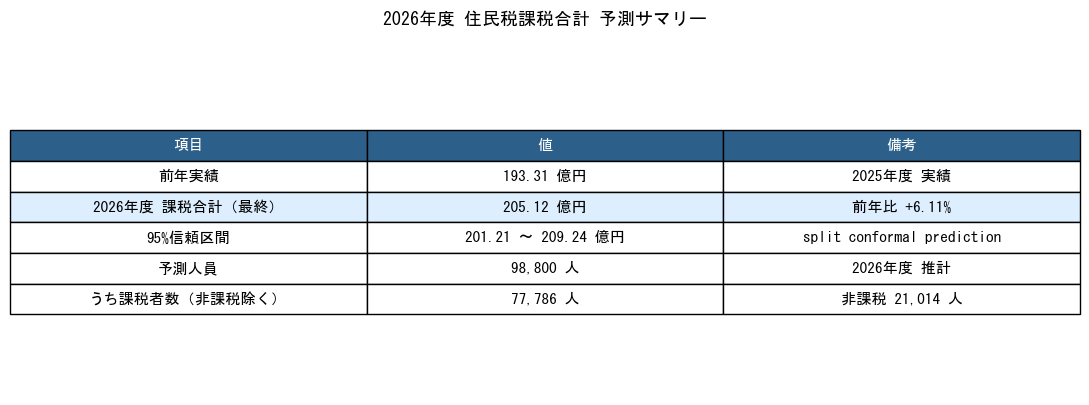

In [14]:
# ── 結果サマリー ─────────────────────────────────────────────────────────
# notebookでは結果を表として描画し、このセルの直下に表示する。
# CLI版（02_src_py/05_predict_2026.py）は同じ内容を print で出力する（値は同一）。
n_taxable   = int((pred_tax != 0).sum())   # 非課税者を除いた課税者数
total_lower = pred_tax_lower.sum() / 1e8
total_upper = pred_tax_upper.sum() / 1e8

rows = [["前年実績", f"{last_year_total:.2f} 億円", f"{df_prep['year'].max()}年度 実績"]]
if feature_reforms:
    reform_effect = total_oku - total_pre_oku
    rows.append(["税制改正補正前", f"{total_pre_oku:.2f} 億円", "推計ベース（補正適用前）"])
    rows.append(["税制改正補正効果", f"{reform_effect:+.2f} 億円",
                 "|".join(r["name"] for r in feature_reforms)])

_final_row = len(rows) + 1   # 表の0行目は列見出しのため +1
rows.append([f"{args.year}年度 課税合計（最終）", f"{total_oku:.2f} 億円",
             f"前年比 {diff / last_year_total * 100:+.2f}%"])
rows.append([f"{CONFORMAL_COVERAGE*100:.0f}%信頼区間",
             f"{total_lower:.2f} 〜 {total_upper:.2f} 億円", "split conformal prediction"])
rows.append(["予測人員", f"{len(pred_df_out):,} 人", f"{args.year}年度 推計"])
rows.append(["うち課税者数（非課税除く）", f"{n_taxable:,} 人",
             f"非課税 {len(pred_df_out) - n_taxable:,} 人"])

fig, ax = plt.subplots(figsize=(11, 0.55 * len(rows) + 1.4))
ax.axis("off")
tbl = ax.table(cellText=rows, colLabels=["項目", "値", "備考"], cellLoc="center", loc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.0, 1.7)
for j in range(3):
    tbl[(0, j)].set_facecolor("#2c5f8a")
    tbl[(0, j)].set_text_props(color="white", fontweight="bold")
for j in range(3):
    tbl[(_final_row, j)].set_facecolor("#ddeeff")   # 最終予測合計の行をハイライト
ax.set_title(f"{args.year}年度 住民税課税合計 予測サマリー", fontsize=13, fontweight="bold", pad=18)
plt.tight_layout()
plt.show()

## 年齢区分別内訳

In [15]:
# 年齢区分別内訳
print("── 年齢区分別内訳 ──")
age_col = "age_group" if "age_group" in pred_df_out.columns else None
if age_col:
    print(pred_df_out.assign(pred_tax_amount=pred_tax).groupby("age_group")["pred_tax_amount"].agg(
        人員="count",
        合計_億円=lambda x: round(x.sum() / 1e8, 2),
        平均_万円=lambda x: round(x.mean() / 1e4, 1),
    ).to_string())

── 年齢区分別内訳 ──
             人員  合計_億円  平均_万円
age_group                    
20-24       812   1.03   12.7
25-29      5956   6.96   11.7
30-34      5976  11.33   19.0
35-39      6093  12.04   19.8
40-44      6623  13.73   20.7
45-49      7275  16.38   22.5
50-54      8305  19.96   24.0
55-59      9124  23.03   25.2
60-64      8027  20.81   25.9
65-69      7213  15.87   22.0
70-74      7028  13.59   19.3
75-79      7751  16.20   20.9
80-84      7107  12.61   17.7
85-89      5219   9.72   18.6
90over     6291  11.87   18.9


---

# 結果の保存

## CSV出力

In [16]:
# CSV 出力
out_cols = ["person_id", "year"]
for c in ["age_group", "income_total", "taxable_income", "collection_type",
          "deduct_tax_furusato", "deduct_tax_housing"]:
    if c in pred_df_out.columns:
        out_cols.append(c)

out_df = pred_df_out[out_cols].copy()
out_df["pred_tax_amount"]                        = pred_tax
out_df[f"pred_tax_lower_{int(CONFORMAL_COVERAGE*100)}"] = pred_tax_lower
out_df[f"pred_tax_upper_{int(CONFORMAL_COVERAGE*100)}"] = pred_tax_upper

out_path = f"data/05out_prediction_{args.year}.csv"
sum_path = f"data/05out_prediction_summary_{args.year}.csv"

out_df.to_csv(out_path, index=False, encoding="utf-8-sig")
pd.DataFrame([{
    "予測年度"        : args.year,
    "予測合計_億円"   : round(total_oku, 2),
    f"CI下限_{int(CONFORMAL_COVERAGE*100)}%_億円": round(total_lower, 2),
    f"CI上限_{int(CONFORMAL_COVERAGE*100)}%_億円": round(total_upper, 2),
    "前年実績_億円"   : round(last_year_total, 2),
    "前年比_億円"     : round(diff, 2),
    "前年比率_%"      : round(diff / last_year_total * 100, 2),
    "予測人員"        : len(out_df),
    "課税者数"        : n_taxable,  # 2026-09-09追加: 非課税者を除いた課税者数
    "適用補正数"      : len(feature_reforms),
    "適用補正名"      : "|".join(r["name"] for r in feature_reforms) if feature_reforms else "なし",
}]).to_csv(sum_path, index=False, encoding="utf-8-sig")

print(f"→ {out_path} に個人別予測を保存")
print(f"→ {sum_path} に集計サマリーを保存")
print("次: python 06_trend_correction.py")

→ data/05out_prediction_2026.csv に個人別予測を保存
→ data/05out_prediction_summary_2026.csv に集計サマリーを保存
次: python 06_trend_correction.py
